In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import wilcoxon, ttest_rel

## Code for plots to compare identical partition to binomial partition

In [ ]:
#Path to the plot data
path_to_plot_data = "/home/gzu5140/Keerthana_b1042/grnInference/plot_data/binomial_partition/"
path_to_plots = "/home/gzu5140/Keerthana_b1042/grnInference/plots/binomial_partition/"
os.makedirs(path_to_plots, exist_ok=True)
path_to_code_repo = "/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER/"

In [3]:
#path to code
import matplotlib.font_manager as fm
# ============================================================
# Fonts / style
# ============================================================
font_paths = [
    f"{path_to_code_repo}/fonts/Arial.ttf",
    f"{path_to_code_repo}/fonts/Arial Bold.ttf",
    f"{path_to_code_repo}/fonts/Arial Italic.ttf",
    f"{path_to_code_repo}/fonts/Arial Bold Italic.ttf",
]

for fp in font_paths:
    try:
        fm.fontManager.addfont(fp)
        print("✔ Loaded font:", fp)
    except Exception as e:
        print("⚠️  Could not load:", fp, "|", e)

plt.rcParams['pdf.fonttype'] = 42  # For PDF export
plt.rcParams['ps.fonttype'] = 42   # For PostScript (EPS) export
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['svg.fonttype'] = "none"
plt.rcParams['mathtext.fontset'] = "cm"
plt.rcParams['axes.labelsize'] = 18      # x/y labels
plt.rcParams['axes.titlesize'] = 20 
plt.rcParams['xtick.labelsize'] = 12     # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 12    # y-axis tick labels
plt.rcParams['legend.fontsize'] = 12     # legend text

✔ Loaded font: /home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER//fonts/Arial.ttf
✔ Loaded font: /home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER//fonts/Arial Bold.ttf
✔ Loaded font: /home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER//fonts/Arial Italic.ttf
✔ Loaded font: /home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER//fonts/Arial Bold Italic.ttf


## Panel 2d

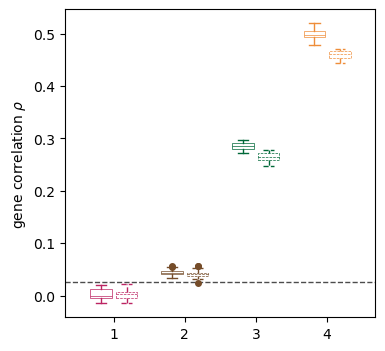

In [16]:
# =========================
# INPUTS (NEW)
# =========================
gene_gene_corr_data_path_1 = f"/home/gzu5140/Keerthana_b1042/grnInference/plot_data/figure_2_data_02012026/gene_gene_matrix_results.csv"
gene_gene_corr_data_path_2 = f"{path_to_plot_data}/gene_gene_matrix_results.csv"

gene_gene_corr_data_1 = pd.read_csv(gene_gene_corr_data_path_1)
gene_gene_corr_data_2 = pd.read_csv(gene_gene_corr_data_path_2)

sim_types_to_plot = ['A_B','A_to_B', 'A_to_B_2_states', 'A_B_2_states']
labels_plot = ["1", "2", "3", "4"]
colors = ['#bc2462', '#754c29', '#006838', '#ee8d39']

# =========================
# COLLECT VALUES (DUPLICATED ON PURPOSE)
# =========================
all_values_1 = []
all_thresholds = []

for sim_type in sim_types_to_plot:
    sim_data = gene_gene_corr_data_1[gene_gene_corr_data_1['sim_type'] == sim_type]
    all_values_1.append(sim_data['g1_g2'].values.tolist())
    all_thresholds.extend(sim_data['threshold'].values.tolist())

all_values_2 = []

for sim_type in sim_types_to_plot:
    sim_data = gene_gene_corr_data_2[gene_gene_corr_data_2['sim_type'] == sim_type]
    all_values_2.append(sim_data['g1_g2'].values.tolist())
    all_thresholds.extend(sim_data['threshold'].values.tolist())

# =========================
# PLOTTING
# =========================
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_facecolor('none')
ax.set_ylabel(r"gene correlation $\rho$")

# Mean threshold
ax.axhline(
    np.mean(all_thresholds),
    linestyle="--",
    color="black",
    linewidth=1,
    alpha=0.7
)

# --- positions (NEW) ---
base_pos = np.arange(1, len(labels_plot) + 1)
offset = 0.18

pos_1 = base_pos - offset
pos_2 = base_pos + offset

# --- boxplots ---
box1 = ax.boxplot(
    all_values_1,
    positions=pos_1,
    widths=0.3,
    patch_artist=True,
    showfliers=True
)

box2 = ax.boxplot(
    all_values_2,
    positions=pos_2,
    widths=0.3,
    patch_artist=True,
    showfliers=True
)

# =========================
# STYLING — FIRST (SOLID)
# =========================
for patch, color in zip(box1['boxes'], colors):
    patch.set_facecolor('none')
    patch.set_edgecolor(color)
    patch.set_linewidth(0.5)

for whisker, color in zip(box1['whiskers'], [c for c in colors for _ in (0, 1)]):
    whisker.set_color(color)

for cap, color in zip(box1['caps'], [c for c in colors for _ in (0, 1)]):
    cap.set_color(color)

for median, color in zip(box1['medians'], colors):
    median.set_color(color)
    median.set_linewidth(0.5)

for flier, color in zip(box1['fliers'], colors):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)
    flier.set_markersize(4)

# =========================
# STYLING — SECOND (DASHED)
# =========================
for patch, color in zip(box2['boxes'], colors):
    patch.set_facecolor('none')
    patch.set_edgecolor(color)
    patch.set_linewidth(0.5)
    patch.set_linestyle('dashed')

for whisker, color in zip(box2['whiskers'], [c for c in colors for _ in (0, 1)]):
    whisker.set_color(color)
    whisker.set_linestyle('dashed')

for cap, color in zip(box2['caps'], [c for c in colors for _ in (0, 1)]):
    cap.set_color(color)
    cap.set_linestyle('dashed')

for median, color in zip(box2['medians'], colors):
    median.set_color(color)
    median.set_linewidth(0.5)
    median.set_linestyle('dashed')

for flier, color in zip(box2['fliers'], colors):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)
    flier.set_markersize(4)

# Disable clipping (Illustrator-safe)
for element_list in (
    box1['boxes'] + box1['whiskers'] + box1['caps'] + box1['medians'] +
    box2['boxes'] + box2['whiskers'] + box2['caps'] + box2['medians']
):
    element_list.set_clip_on(False)

# x-axis
ax.set_xticks(base_pos)
ax.set_xticklabels(labels_plot)

plt.savefig(f'{path_to_plots}/gene_gene_correlation.png', 
           format='png', 
           bbox_inches='tight',
           facecolor='none',      # Transparent figure background
           edgecolor='none',      # No edge color
           transparent=True)      # Ensure transparency
plt.savefig(f'{path_to_plots}/gene_gene_correlation.svg', 
           format='svg', 
           bbox_inches='tight',
           facecolor='none',      # Transparent figure background
           edgecolor='none',      # No edge color
           transparent=True)      # Ensure transparency
plt.savefig(f'{path_to_plots}/gene_gene_correlation.pdf', 
           format='pdf', 
           bbox_inches='tight',
           facecolor='none',      # Transparent figure background
           edgecolor='none',      # No edge color
           transparent=True)      # Ensure transparency

plt.show()

## Panel 2e

/tmp/ipykernel_2913787/6342370.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_threshold = ax_threshold.boxplot(all_thresholds, labels=labels_plot,


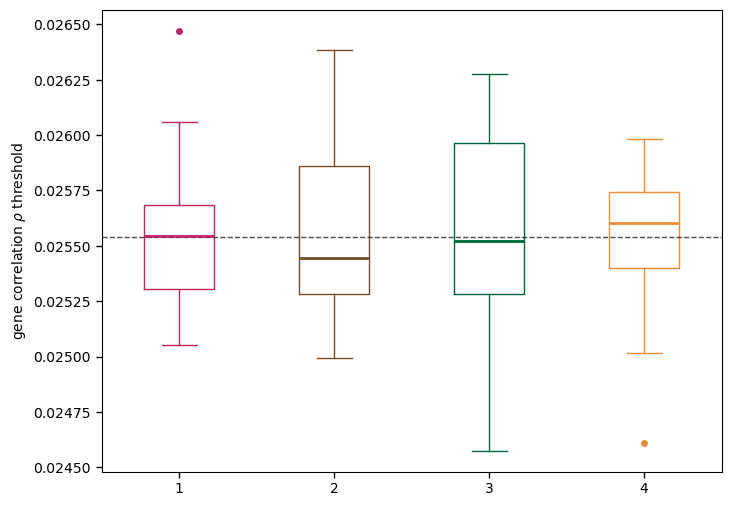

In [6]:
# Create standalone threshold plot
fig_threshold, ax_threshold = plt.subplots(figsize=(8, 6))

# Create threshold boxplot
box_threshold = ax_threshold.boxplot(all_thresholds, labels=labels_plot, 
                                   patch_artist=False, showfliers=True)
ax_threshold.axhline(np.mean(flat_thresholds), linestyle="--", color="black", linewidth=1, alpha=0.7)

# Style threshold boxplot with matching colors
for patch, color in zip(box_threshold['boxes'], colors):
    patch.set_color(color)

for whisker, color in zip(box_threshold['whiskers'], [c for c in colors for _ in (0, 1)]):
    whisker.set_color(color)

for cap, color in zip(box_threshold['caps'], [c for c in colors for _ in (0, 1)]):
    cap.set_color(color)

for median, color in zip(box_threshold['medians'], colors):
    median.set_color(color)
    median.set_linewidth(2)

# Style outliers
for flier, color in zip(box_threshold['fliers'], colors):
    if len(flier.get_data()[0]) > 0:
        flier.set_markerfacecolor(color)
        flier.set_markeredgecolor(color)
        flier.set_markersize(4)

# DISABLE CLIPPING
for element_list in [box_threshold['boxes'], box_threshold['whiskers'], box_threshold['caps'], box_threshold['medians']]:
    for element in element_list:
        element.set_clip_on(False)

# Style axes
ax_threshold.tick_params(
    axis='both',
    which='both',
    bottom=True, top=False, left=True, right=False,
    # labelbottom=False, labelleft=False,
    length=4, width=1
)
plt.ylabel(r"gene correlation $\rho$ threshold")
# Save threshold plot
# plt.savefig(f'{path_to_plots}/gene_gene_correlation_threshold_boxplot.svg', 
#            format='svg', 
#            bbox_inches='tight',
#            facecolor='none',
#            edgecolor='none',
#            transparent=True)
# plt.savefig(f'{path_to_plots}/gene_gene_correlation_threshold_boxplot.pdf', 
#            format='pdf', 
#            bbox_inches='tight',
#            facecolor='none',
#            edgecolor='none',
#            transparent=True)

plt.show()

## Panel 2f and 2g

In [7]:
# Load the data
random_correlation_path = f"{path_to_plot_data}/random_matrix_results.csv"
twin_correlation_t1_path= f"{path_to_plot_data}/twin_t1_matrix_results.csv"
random_correlation_data = pd.read_csv(random_correlation_path)
twin_correlation_t1_data = pd.read_csv(twin_correlation_t1_path)

In [8]:
import pandas as pd

# Load data about twin correlation, z-scores and median of random pair correlations
loaded_df = pd.read_csv(f"{path_to_plot_data}/twins_random_zscore_summary.csv")

# Helper function: extract list for a specific network + metric
def extract_list(df, net, metric):
    return df[(df.network_type == net) & (df.metric == metric)]["values"].tolist()

# === Reconstruct all 9 lists ===

A_to_B_medians = extract_list(loaded_df, "A_to_B", "medians")
A_to_B_z_scores = extract_list(loaded_df, "A_to_B", "z_scores")
A_to_B_thresholds = extract_list(loaded_df, "A_to_B", "z_threshold_list")

A_to_B_2_states_medians = extract_list(loaded_df, "A_to_B_2_states", "medians")
A_to_B_2_states_z_scores = extract_list(loaded_df, "A_to_B_2_states", "z_scores")
A_to_B_2_states_thresholds = extract_list(loaded_df, "A_to_B_2_states", "z_threshold_list")

A_B_2_states_medians = extract_list(loaded_df, "A_B_2_states", "medians")
A_B_2_states_z_scores = extract_list(loaded_df, "A_B_2_states", "z_scores")
A_B_2_states_thresholds = extract_list(loaded_df, "A_B_2_states", "z_threshold_list")


In [9]:
sim_types_to_plot = ['A_to_B', 'A_to_B_2_states', 'A_B_2_states']
# random-pair correlation medians
random_correlation_medians = [
    A_to_B_medians,
    A_to_B_2_states_medians,
    A_B_2_states_medians,
]

# Collect data for plotting
all_data = []
all_colors = []
positions = []
z_scores = [A_to_B_z_scores, A_to_B_2_states_z_scores, A_B_2_states_z_scores]
z_score_thresholds = [A_to_B_thresholds, A_to_B_2_states_thresholds, A_B_2_states_thresholds]
pos = 1
colors = ['#754c29', '#006838', '#ee8d39']
for i, sim_type in enumerate(sim_types_to_plot):
    print(i)
    # 1. Use random correlation medians
    random_vals = np.array(random_correlation_medians[i])
    random_vals = random_vals[~np.isnan(random_vals)]
    
    # 2. Get twin correlation data from CSV
    twin_sim = twin_correlation_t1_data[twin_correlation_t1_data['sim_type'] == sim_type]
    twin_vals = twin_sim['g2_g1'].values  # Adjust column name if needed
    
    if len(random_vals) > 0 and len(twin_vals) > 0:
        # Calculate 1st percentile threshold from random medians        
        # Add to plotting data (random medians first, then twin)
        all_data.extend([random_vals, twin_vals])
        all_colors.extend([colors[i], colors[i]])
        positions.extend([pos, pos + 1])       
        pos += 3  # Space between groups
    else:
        print(f"Warning: {sim_type} missing data - Random: {len(random_vals)}, Twin: {len(twin_vals)}")


0
1
2


2
5
-0.0257957534192285
0.16552707810473635
0.34600772860264684


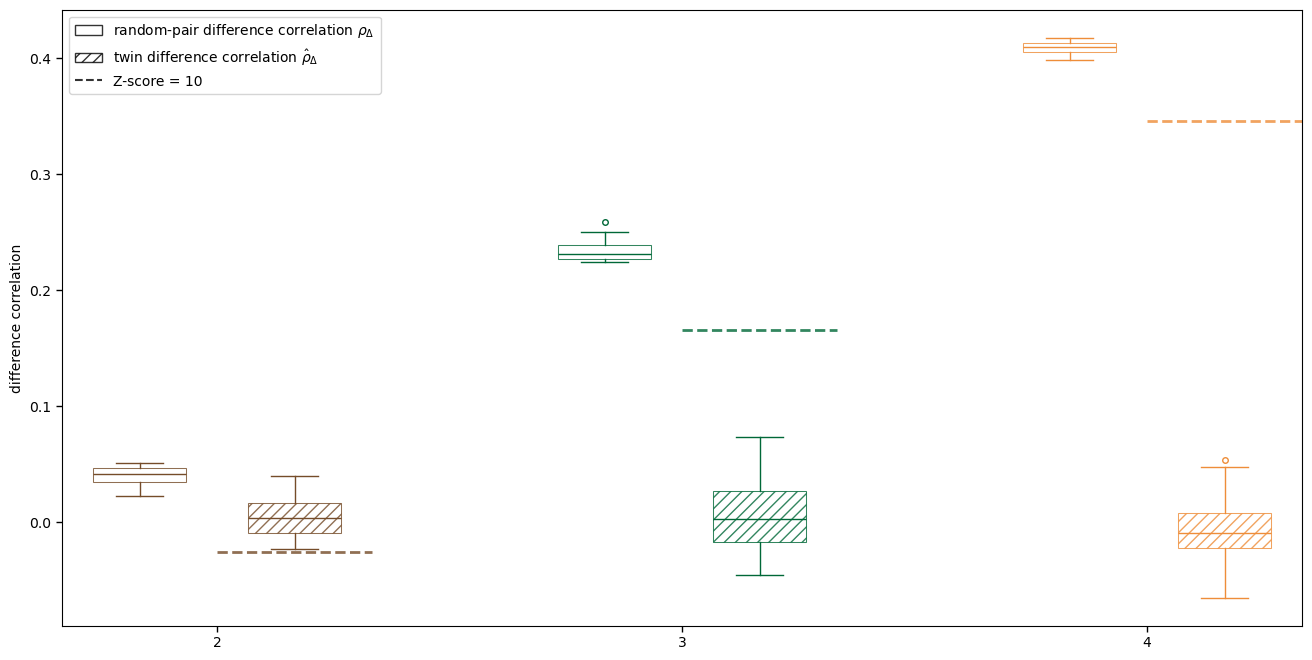

In [10]:
if len(all_data) > 0:
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # REMOVE ALL BACKGROUNDS
    fig.patch.set_facecolor('none')  # Figure background transparent
    ax.set_facecolor('none')         # Axes background transparent

    # Create boxplot with different styles
    box = ax.boxplot(all_data, positions=positions, patch_artist=True, showfliers=True, widths=0.6)
    
    for i, (median_line, color) in enumerate(zip(box['medians'], all_colors)):
        median_line.set_color(color)
        median_line.set_visible(True)
    
    # Color and style the boxes differently for random vs twin
    for i, (patch, color) in enumerate(zip(box['boxes'], all_colors)):
        if i % 2 == 0:  # Random boxes (even indices)
            patch.set_facecolor('none')
            patch.set_edgecolor(color)
            patch.set_linewidth(0.75)
            patch.set_alpha(0.8)
        else:  # Twin boxes (odd indices)
            patch.set_facecolor("none")
            patch.set_edgecolor(color)  # Black outline
            patch.set_linewidth(0.75)
            hatch = '///'  # Define the hatch pattern
            patch.set_hatch(hatch)  # Hatching for twin boxes
            patch.set_linestyle('-')   # Solid outline for twin
            patch.set_alpha(0.8)
        # DISABLE CLIPPING for Illustrator compatibility
        patch.set_clip_on(False)

    # Style whiskers, caps, and medians differently
    for i, whisker in enumerate(box['whiskers']):
        whisker.set_color(all_colors[i//2])
        whisker.set_linewidth(1)
        whisker.set_clip_on(False)
        if (i // 2) % 2 == 0:  # Random whiskers
            whisker.set_linestyle('-')
        else:  # Twin whiskers
            whisker.set_linestyle('-')

    for i, cap in enumerate(box['caps']):
        cap.set_color(all_colors[i//2])
        cap.set_linewidth(1)
        cap.set_clip_on(False)
        if (i // 2) % 2 == 0:  # Random caps
            cap.set_linestyle('-')
        else:  # Twin caps
            cap.set_linestyle('-')

    for i, flier in enumerate(box['fliers']):
        if len(flier.get_data()[0]) > 0:
            print(i)
            flier.set_markerfacecolor('none')
            flier.set_markeredgecolor(all_colors[i])
            flier.set_markersize(4)

    # Add z-score = -10 threshold lines for each group
    z_score_threshold = -10
    group_x_ranges = [(0.5, 2.5), (3.5, 5.5), (6.5, 8.5)]  # x-ranges for each group
    for i, (x_start, x_end) in enumerate(group_x_ranges):
        # Calculate where z-score = -10 would be for each group
        random_mean = np.mean(all_data[i*2])  # Random medians for this group
        random_std = np.std(all_data[i*2])
        z_10_threshold = np.median(z_score_thresholds[i])#random_mean + (z_score_threshold * random_std)
        print(z_10_threshold)
        ax.hlines(z_10_threshold, x_start+1, x_end, 
                     colors=colors[i], linestyles='--', linewidth=2, alpha=0.8)


    # Set x-axis labels
    group_centers = [1.5, 4.5, 7.5]  # Centers of each pair
    ax.set_xticks(group_centers)
    ax.set_xticklabels([2, 3, 4])

    # Add legend with different styles
    legend_elements = [
        Patch(facecolor='none', edgecolor='black', linestyle='-',
              alpha=0.8, label = r"random-pair difference correlation $\rho_\Delta$"),
        Patch(facecolor='none', edgecolor='black', linestyle='-',
              alpha=0.8, hatch='///', label = r"twin difference correlation $\hat{\rho}_\Delta$"),
        Line2D([0], [0], color='black', linestyle='--', alpha=0.8, label = "Z-score = 10")
    ]
    ax.legend(handles=legend_elements, loc='upper left')

    # Clean styling for Illustrator
    ax.set_ylabel('difference correlation')
    ax.set_title('')
    
    ax.tick_params(
            axis='both',
            which='both',
            bottom=True, top=False, left=True, right=False,
            # labelbottom=False, labelleft=False,
            length=4, width=1
        )

    # # Save with Illustrator-friendly settings
    # plt.savefig(f"{path_to_plots}/twin_correlation.svg", 
    #            format="svg", 
    #            bbox_inches='tight',
    #            facecolor='none',      # Transparent figure background
    #            edgecolor='none',      # No edge color
    #            transparent=True)      # Ensure transparency
    # plt.savefig(f"{path_to_plots}/twin_correlation.png", 
    #            format="png", 
    #            bbox_inches='tight',
    #            facecolor='none',      # Transparent figure background
    #            edgecolor='none',      # No edge color
    #            transparent=True)      # Ensure transparency
    # plt.savefig(f"{path_to_plots}/twin_correlation.pdf", 
    #            format="pdf", 
    #            bbox_inches='tight',
    #            facecolor='none',      # Transparent figure background
    #            edgecolor='none',      # No edge color
    #            transparent=True)      # Ensure transparency
    
    plt.show()
else:
    print("No valid data available for plotting!")


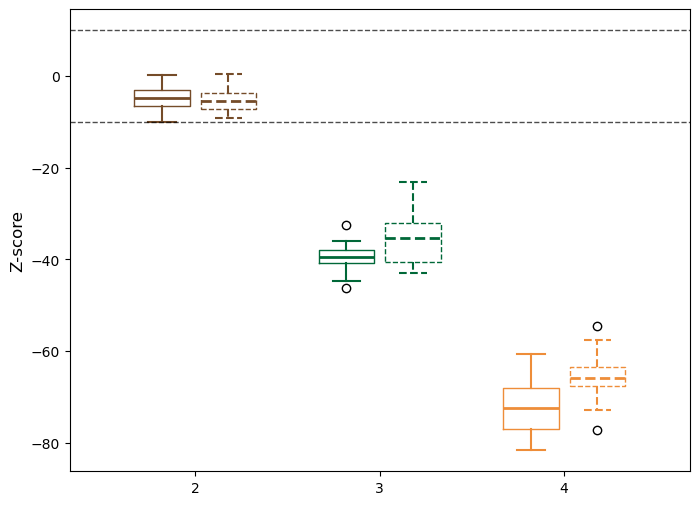

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# LOAD TWO DATASETS (NEW)
# =========================
loaded_df_1 = pd.read_csv(f"/home/gzu5140/Keerthana_b1042/grnInference/plot_data/figure_2_data/twins_random_zscore_summary.csv")
loaded_df_2 = pd.read_csv(f"{path_to_plot_data}/twins_random_zscore_summary.csv")

# Helper already in your code (kept)
def extract_list(df, net, metric):
    return df[(df.network_type == net) & (df.metric == metric)]["values"].tolist()

# =========================
# RECONSTRUCT LISTS — DATASET 1
# =========================
A_to_B_z_scores_1 = extract_list(loaded_df_1, "A_to_B", "z_scores")
A_to_B_2_states_z_scores_1 = extract_list(loaded_df_1, "A_to_B_2_states", "z_scores")
A_B_2_states_z_scores_1 = extract_list(loaded_df_1, "A_B_2_states", "z_scores")

# =========================
# RECONSTRUCT LISTS — DATASET 2
# =========================
A_to_B_z_scores_2 = extract_list(loaded_df_2, "A_to_B", "z_scores")
A_to_B_2_states_z_scores_2 = extract_list(loaded_df_2, "A_to_B_2_states", "z_scores")
A_B_2_states_z_scores_2 = extract_list(loaded_df_2, "A_B_2_states", "z_scores")

# =========================
# PLOTTING SETUP
# =========================
colors = ['#754c29', '#006838', '#ee8d39']

z_scores_1 = [
    A_to_B_z_scores_1,
    A_to_B_2_states_z_scores_1,
    A_B_2_states_z_scores_1,
]

z_scores_2 = [
    A_to_B_z_scores_2,
    A_to_B_2_states_z_scores_2,
    A_B_2_states_z_scores_2,
]

fig_zscore = plt.figure(figsize=(8, 6))
ax_zscore = fig_zscore.add_subplot(111)

# --- positions (NEW) ---
base_pos = np.arange(1, 4)
offset = 0.18

pos_1 = base_pos - offset
pos_2 = base_pos + offset

# =========================
# BOXPLOTS
# =========================
z_box_1 = ax_zscore.boxplot(
    z_scores_1,
    positions=pos_1,
    widths=0.3,
    patch_artist=False,
    showfliers=True
)

z_box_2 = ax_zscore.boxplot(
    z_scores_2,
    positions=pos_2,
    widths=0.3,
    patch_artist=False,
    showfliers=True
)

# =========================
# STYLING — SOLID
# =========================
for i, box in enumerate(z_box_1['boxes']):
    box.set_color(colors[i])
    box.set_clip_on(False)

for i, median in enumerate(z_box_1['medians']):
    median.set_color(colors[i])
    median.set_linewidth(2)
    median.set_clip_on(False)

for i, whisker in enumerate(z_box_1['whiskers']):
    whisker.set_color(colors[i // 2])
    whisker.set_linewidth(1.5)
    whisker.set_clip_on(False)

for i, cap in enumerate(z_box_1['caps']):
    cap.set_color(colors[i // 2])
    cap.set_linewidth(1.5)
    cap.set_clip_on(False)

# =========================
# STYLING — DASHED
# =========================
for i, box in enumerate(z_box_2['boxes']):
    box.set_color(colors[i])
    box.set_linestyle('dashed')
    box.set_clip_on(False)

for i, median in enumerate(z_box_2['medians']):
    median.set_color(colors[i])
    median.set_linewidth(2)
    median.set_linestyle('dashed')
    median.set_clip_on(False)

for i, whisker in enumerate(z_box_2['whiskers']):
    whisker.set_color(colors[i // 2])
    whisker.set_linewidth(1.5)
    whisker.set_linestyle('dashed')
    whisker.set_clip_on(False)

for i, cap in enumerate(z_box_2['caps']):
    cap.set_color(colors[i // 2])
    cap.set_linewidth(1.5)
    cap.set_linestyle('dashed')
    cap.set_clip_on(False)

# =========================
# Z-SCORE THRESHOLDS (UNCHANGED)
# =========================
ax_zscore.axhline(-1 * z_score_threshold, linestyle="--",
                  color="black", linewidth=1, alpha=0.7)
ax_zscore.axhline(z_score_threshold, linestyle="--",
                  color="black", linewidth=1, alpha=0.7)

# =========================
# AXES
# =========================
ax_zscore.set_xticks(base_pos)
ax_zscore.set_xticklabels(["2", "3", "4"])
ax_zscore.set_ylabel("Z-score", fontsize=12)
ax_zscore.tick_params(labelsize=10)

plt.savefig(f"{path_to_plots}/zscore_boxplot.pdf", 
           format="pdf", 
           bbox_inches='tight',
           facecolor='none',
           edgecolor='none',
           transparent=True)
plt.savefig(f"{path_to_plots}/zscore_boxplot.svg", 
           format="svg", 
           bbox_inches='tight',
           facecolor='none',
           edgecolor='none',
           transparent=True)
plt.savefig(f"{path_to_plots}/zscore_boxplot.png", 
           format="png", 
           bbox_inches='tight',
           facecolor='none',
           edgecolor='none',
           transparent=True)
plt.show()


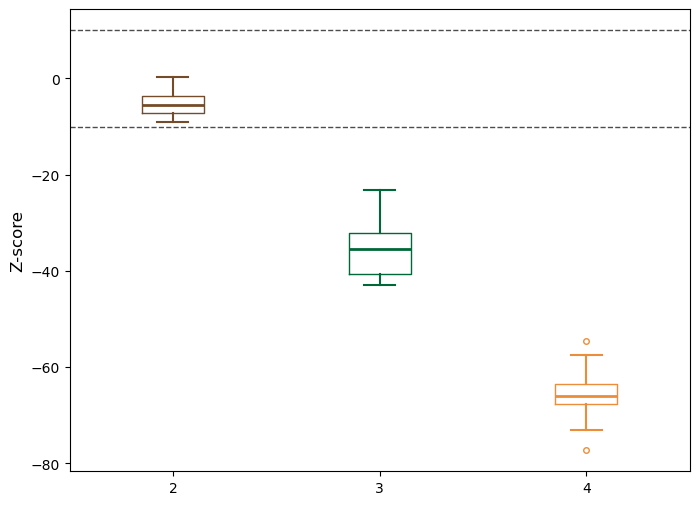

In [11]:
fig_zscore = plt.figure(figsize=(8, 6))
ax_zscore = fig_zscore.add_subplot(111)

# Create z-score boxplot using the z_scores calculated above
z_box = ax_zscore.boxplot(z_scores, patch_artist=False, showfliers=True)

# Style z-score boxplot with matching colors
for i, patch in enumerate(z_box['boxes']):
    patch.set_color(colors[i])
    patch.set_clip_on(False)

for i, median in enumerate(z_box['medians']):
    median.set_color(colors[i])
    median.set_linewidth(2)
    median.set_clip_on(False)

for i, whisker in enumerate(z_box['whiskers']):
    whisker.set_color(colors[i//2])
    whisker.set_linewidth(1.5)
    whisker.set_clip_on(False)

for i, cap in enumerate(z_box['caps']):
    cap.set_color(colors[i//2])
    cap.set_linewidth(1.5)
    cap.set_clip_on(False)

# Style outliers
for i, flier in enumerate(z_box['fliers']):
    if len(flier.get_data()[0]) > 0:
        flier.set_markerfacecolor("none")
        flier.set_markeredgecolor(colors[i])
        flier.set_markersize(4)

# Add z-score thresholds
ax_zscore.axhline(-1*z_score_threshold, linestyle="--", color="black", linewidth=1, alpha=0.7, label="z-score threshold")
ax_zscore.axhline(z_score_threshold, linestyle="--", color="black", linewidth=1, alpha=0.7)


# Set labels and styling
ax_zscore.set_xticks([1,2,3])
ax_zscore.set_xticklabels(["2", "3", "4"])
ax_zscore.set_ylabel("Z-score", fontsize=12)
ax_zscore.tick_params(labelsize=10)
# ax_zscore.legend(fontsize=10)

# Save z-score plot
plt.savefig(f"{path_to_plots}/zscore_boxplot.pdf", 
           format="pdf", 
           bbox_inches='tight',
           facecolor='none',
           edgecolor='none',
           transparent=True)
plt.savefig(f"{path_to_plots}/zscore_boxplot.svg", 
           format="svg", 
           bbox_inches='tight',
           facecolor='none',
           edgecolor='none',
           transparent=True)
plt.savefig(f"{path_to_plots}/zscore_boxplot.png", 
           format="png", 
           bbox_inches='tight',
           facecolor='none',
           edgecolor='none',
           transparent=True)

plt.show()

## Panel 2h

In [12]:
twin_correlation_t1_path = f"{path_to_plot_data}/twin_t1_matrix_results.csv"
twin_correlation_t1_data = pd.read_csv(twin_correlation_t1_path)
twin_correlation_t2_path = f"{path_to_plot_data}/twin_t2_matrix_results.csv"
twin_correlation_t2_data = pd.read_csv(twin_correlation_t2_path)

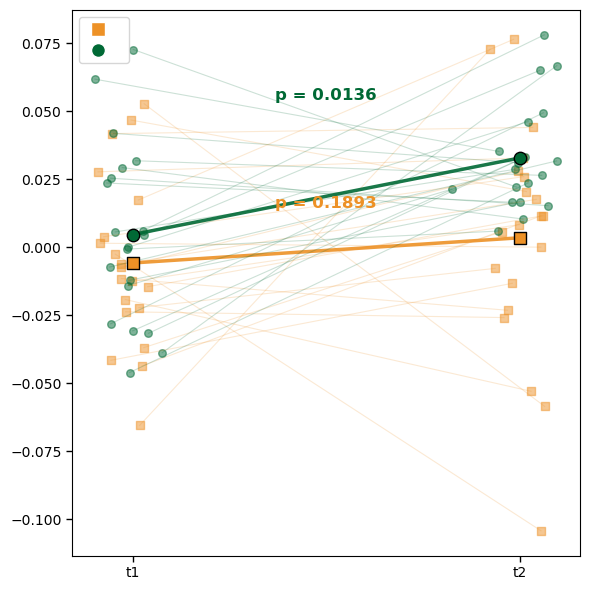

In [14]:
sim_types_to_plot = ['A_B_2_states', 'A_to_B_2_states']
colors = ['#ed9126', '#006935']
markers = ["s", "o"]
fig, ax = plt.subplots(figsize=(6, 6))

# REMOVE ALL BACKGROUNDS
#figure_2_v3_2x_cells  # Figure background transparent
ax.set_facecolor('none')         # Axes background transparent

x_positions = {'t1': 0.2, 't2': 0.8}  # shift away from the edges
mean_points = {}
differences = []

# Store legend handles
legend_handles = []

for i, (sim_type, color, marker) in enumerate(zip(sim_types_to_plot, colors, markers)):
    # Get data from CSV files
    t1_sim_data = twin_correlation_t1_data[twin_correlation_t1_data['sim_type'] == sim_type]
    t2_sim_data = twin_correlation_t2_data[twin_correlation_t2_data['sim_type'] == sim_type]
    
    t1_vals = (t1_sim_data['g2_g1'].values)  # Adjust column name if needed
    t2_vals = (t2_sim_data['g2_g1'].values)  # Adjust column name if needed
    differences = list(t2_vals - t1_vals) 
    mean = np.mean(differences)
    std_dev = np.std(differences)
    # --- Perform Wilcoxon signed-rank test ---
    stat, p_value = wilcoxon(t1_vals, t2_vals)
    
    # Format p-value
    p_text = f"p = {p_value:.4f}"

    # --- Jittered strip plot ---
    jitter_t1 = np.random.normal(x_positions['t1'], 0.03, size=len(t1_vals))
    jitter_t2 = np.random.normal(x_positions['t2'], 0.03, size=len(t2_vals))

    scatter1 = ax.scatter(jitter_t1, t1_vals, color=color, alpha=0.5, s=30, marker = marker)
    scatter2 = ax.scatter(jitter_t2, t2_vals, color=color, alpha=0.5, s=30, marker = marker)
    
    # DISABLE CLIPPING for scatter plots
    scatter1.set_clip_on(False)
    scatter2.set_clip_on(False)

    # --- Light individual connection lines ---
    for x1, y1, x2, y2 in zip(jitter_t1, t1_vals, jitter_t2, t2_vals):
        line = ax.plot([x1, x2], [y1, y2], color=color, alpha=0.2, linewidth=0.8)[0]
        line.set_clip_on(False)

    # --- Mean connection ---
    mean_t1, mean_t2 = np.mean(t1_vals), np.mean(t2_vals)
    mean_points[sim_type] = (mean_t1, mean_t2)

    mean_line = ax.plot(
        [x_positions['t1'], x_positions['t2']],
        [mean_t1, mean_t2],
        color=color,
        linewidth=2.5,
        alpha=0.9
    )[0]

    mean_line.set_clip_on(False)
    
    mean_scatter = ax.scatter(
        [x_positions['t1'], x_positions['t2']],
        [mean_t1, mean_t2],
        color=color,
        s=80,
        edgecolor='black',
        zorder=3,
        marker = marker,
        # label=f"{sim_type} mean"
    )
    mean_scatter.set_clip_on(False)
    
    # Store legend handle (using the mean scatter plot for cleaner legend)
    legend_handles.append(plt.Line2D([0], [0], marker=marker, color='w', 
                                   markerfacecolor=color, markersize=10, 
                                   linewidth=0))
    
    # --- Add p-value text above the mean line ---
    # Position text above the higher of the two mean points
    text_y = max(mean_t1, mean_t2) + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.05 * (i + 1)
    text_x = np.mean([x_positions['t1'], x_positions['t2']])
    
    ax.text(text_x, text_y, p_text, 
           color=color, 
           fontsize=12, 
           fontweight='bold',
           ha='center', 
           va='bottom')

# Add legend with no text labels
ax.legend(legend_handles, ['', ''], loc='upper left', frameon=True)

# --- Aesthetics ---
ax.set_xticks([x_positions['t1'], x_positions['t2']])
ax.set_xticklabels(['t1', 't2'])
ax.set_ylabel("")
# ax.set_title("t1 = 1h, t2= 20h, Wilcoxon test")
# ax.grid(True, axis='y', alpha=0.3)

# Style tick parameters for clean look
ax.tick_params(
    axis='both',
    which='both',
    bottom=True, top=False, left=True, right=False,
    labelbottom=True, labelleft=True,  # Hides tick labels
    length=4, width=1
)
ax.grid(False)  # Remove grid lines for final version

plt.tight_layout()

# Save with Illustrator-friendly settings
plt.savefig(f"{path_to_plots}/change_in_twin_correlation.png", 
           format="png",
           bbox_inches='tight',
           facecolor='none',      # Transparent figure background
           edgecolor='none',      # No edge color
           transparent=True)      # Ensure transparency
plt.savefig(f"{path_to_plots}/change_in_twin_correlation.svg", 
           format="svg",
           bbox_inches='tight',
           facecolor='none',      # Transparent figure background
           edgecolor='none',      # No edge color
           transparent=True)      # Ensure transparency
plt.savefig(f"{path_to_plots}/change_in_twin_correlation.svg", 
           format="svg",
           bbox_inches='tight',
           facecolor='none',      # Transparent figure background
           edgecolor='none',      # No edge color
           transparent=True)      # Ensure transparency
plt.show()

In [6]:
df2

,Unnamed: 0,gene_1_to_gene_2,gene_2_to_gene_1,pvalue_12,pvalue_21,threshold_12,threshold_21,threshold_combined,Condition,File
0,0,-0.001450,0.007271,0.9302,0.6908,0.042548,0.042781,0.042613,A_B,df_rows_0_0_06022026_160944_ncells_6000_A_B_bi...
1,1,0.024510,0.026803,0.1732,0.1430,0.044016,0.043858,0.043990,A_B,df_rows_0_0_06022026_163206_ncells_6000_A_B_bi...
2,2,-0.007334,-0.009912,0.6842,0.5904,0.044167,0.043239,0.043833,A_B,df_rows_0_0_06022026_162525_ncells_6000_A_B_bi...
3,3,-0.024031,-0.014734,0.1842,0.4200,0.042598,0.042799,0.042538,A_B,df_rows_0_0_06022026_155630_ncells_6000_A_B_bi...
4,4,0.015302,-0.023973,0.3948,0.1892,0.042563,0.042705,0.042478,A_B,df_rows_0_0_06022026_162056_ncells_6000_A_B_bi...
5,5,-0.015520,-0.003274,0.4024,0.8456,0.042429,0.042116,0.042155,A_B,df_rows_0_0_06022026_161842_ncells_6000_A_B_bi...
6,6,0.027935,0.028253,0.1194,0.1306,0.042660,0.042171,0.042090,A_B,df_rows_0_0_06022026_163634_ncells_6000_A_B_bi...
7,7,0.010283,-0.022832,0.5672,0.2076,0.042290,0.042533,0.042297,A_B,df_rows_0_0_06022026_160730_ncells_6000_A_B_bi...
8,8,-0.009326,0.006409,0.6104,0.7264,0.042702,0.042789,0.042697,A_B,df_rows_0_0_06022026_162310_ncells_6000_A_B_bi...
9,9,0.015560,0.017330,0.3994,0.3466,0.043803,0.043469,0.043528,A_B,df_rows_0_0_06022026_161159_ncells_6000_A_B_bi...


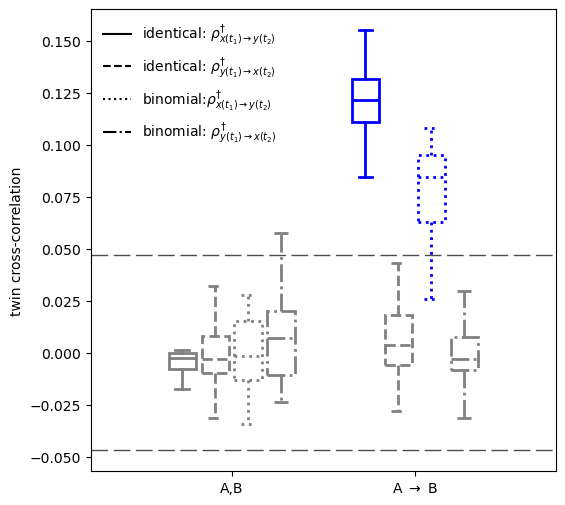

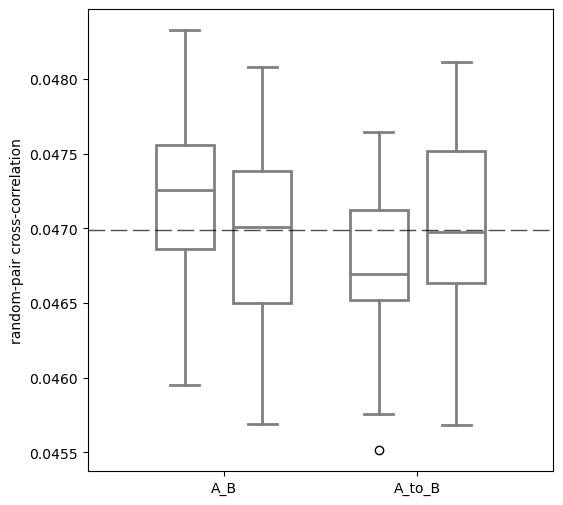

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import os

def create_box_plots(df1, df2, save_dir):

    # ==================================================
    # FILTER + NORMALIZE (OLD FORMAT, BOTH FILES)
    # ==================================================
    keep_conditions = ['A_B', 'A_to_B']

    def normalize(df):
        df = df[df['Condition'].isin(keep_conditions)].copy()
        return df.rename(columns={
            'Condition': 'sim_type',
            'gene_1_to_gene_2': 'g12',
            'gene_2_to_gene_1': 'g21'
        })

    df1 = normalize(df1)
    df2 = normalize(df2)

    conditions = keep_conditions

    # ==================================================
    # COLLECT THRESHOLDS (FROM DF1, USED FOR BOTH)
    # ==================================================
    all_thresholds_12 = []
    all_thresholds_21 = []
    all_thresholds = []

    for cond in conditions:
        d = df1[df1['sim_type'] == cond]
        all_thresholds_12.append(d['threshold_12'].values)
        all_thresholds_21.append(d['threshold_21'].values)
        all_thresholds.append(d['threshold_combined'].values)

    flat_thresholds = np.concatenate(all_thresholds)

    # ==================================================
    # COLLECT VALUES (BOTH FILES)
    # ==================================================
    v12_f1, v21_f1 = [], []
    v12_f2, v21_f2 = [], []

    for cond in conditions:
        d1 = df1[df1['sim_type'] == cond]
        d2 = df2[df2['sim_type'] == cond]

        v12_f1.append(d1['g12'].values)
        v21_f1.append(d1['g21'].values)

        v12_f2.append(d2['g12'].values)
        v21_f2.append(d2['g21'].values)

    # ==================================================
    # COLOR LOGIC (UNCHANGED)
    # ==================================================
    def get_threshold_color(values, thresholds):
        med = np.median(values)
        thr = np.mean(thresholds)
        if med > thr:
            return 'blue'
        elif med < -thr:
            return 'red'
        else:
            return 'grey'

    # ==================================================
    # PLOT 1 — CORRELATIONS
    # ==================================================
    fig, ax = plt.subplots(figsize=(6, 6))
    fig.patch.set_facecolor('none')
    ax.set_facecolor('none')

    base = np.arange(1, len(conditions) + 1)
    dx = 0.18

    pos_f1_12 = base - 1.5 * dx
    pos_f1_21 = base - 0.5 * dx
    pos_f2_12 = base + 0.5 * dx
    pos_f2_21 = base + 1.5 * dx

    box_f1_12 = ax.boxplot(v12_f1, positions=pos_f1_12,
                           widths=0.15, patch_artist=True, showfliers=False)
    box_f1_21 = ax.boxplot(v21_f1, positions=pos_f1_21,
                           widths=0.15, patch_artist=True, showfliers=False)
    box_f2_12 = ax.boxplot(v12_f2, positions=pos_f2_12,
                           widths=0.15, patch_artist=True, showfliers=False)
    box_f2_21 = ax.boxplot(v21_f2, positions=pos_f2_21,
                           widths=0.15, patch_artist=True, showfliers=False)

    # ---- styling helper (SAFE FOR Line2D) ----
    def style_boxplot(box, linestyle):
        for b in box['boxes']:
            b.set_facecolor('none')
            b.set_linewidth(2)
            b.set_linestyle(linestyle)
            b.set_clip_on(False)
        for k in ['whiskers', 'caps', 'medians']:
            for ln in box[k]:
                ln.set_linewidth(2)
                ln.set_linestyle(linestyle)
                ln.set_clip_on(False)

    style_boxplot(box_f1_12, '-')
    style_boxplot(box_f1_21, '--')
    style_boxplot(box_f2_12, ':')
    style_boxplot(box_f2_21, '-.')

    # ---- threshold colouring (BOTH FILES, SAME THRESHOLDS) ----
    def color_by_threshold(box, values, thresholds):
        colors = [get_threshold_color(v, t) for v, t in zip(values, thresholds)]
        colors2 = [c for c in colors for _ in (0, 1)]

        for b, c in zip(box['boxes'], colors):
            b.set_edgecolor(c)

        for ln, c in zip(box['whiskers'], colors2):
            ln.set_color(c)
        for ln, c in zip(box['caps'], colors2):
            ln.set_color(c)
        for ln, c in zip(box['medians'], colors):
            ln.set_color(c)

    color_by_threshold(box_f1_12, v12_f1, all_thresholds_12)
    color_by_threshold(box_f1_21, v21_f1, all_thresholds_21)
    color_by_threshold(box_f2_12, v12_f2, all_thresholds_12)
    color_by_threshold(box_f2_21, v21_f2, all_thresholds_21)

    # ---- threshold guide lines ----
    ax.axhline(np.mean(flat_thresholds), linestyle='--',
               color='black', linewidth=1, alpha=0.7, dashes=(12,4))
    ax.axhline(-np.mean(flat_thresholds), linestyle='--',
               color='black', linewidth=1, alpha=0.7, dashes=(12,4))

    folder_names = ["A,B", r"A $\rightarrow$ B"]
    ax.set_xticks(range(1, len(conditions) + 1))
    ax.set_xticklabels(folder_names[:len(conditions)])
    ax.set_ylabel("twin cross-correlation")

    ax.legend(handles=[
        mlines.Line2D([], [], color='black', linestyle='-',  label=r'identical: $\rho^{\dagger}_{x(t_{1}) \to y(t_{2})}$'),
        mlines.Line2D([], [], color='black', linestyle='--', label=r'identical: $\rho^{\dagger}_{y(t_{1}) \to x(t_{2})}$'),
        mlines.Line2D([], [], color='black', linestyle=':',  label=r'binomial:$\rho^{\dagger}_{x(t_{1}) \to y(t_{2})}$'),
        mlines.Line2D([], [], color='black', linestyle='-.', label=r'binomial: $\rho^{\dagger}_{y(t_{1}) \to x(t_{2})}$'),
    ], frameon=False)

    plt.savefig(os.path.join(save_dir, "correlations_with_thresholds.pdf"),
                bbox_inches='tight', facecolor='none', transparent=True)
    plt.savefig(os.path.join(save_dir, "correlations_with_thresholds.svg"),
                bbox_inches='tight', facecolor='none', transparent=True)
    plt.show()

    # ==================================================
    # PLOT 2 — THRESHOLD BOXPLOTS
    # ==================================================
    fig, ax = plt.subplots(figsize=(6, 6))
    fig.patch.set_facecolor('none')
    ax.set_facecolor('none')

    pos_12 = base - 0.2
    pos_21 = base + 0.2

    box_t12 = ax.boxplot(all_thresholds_12, positions=pos_12,
                         widths=0.3, patch_artist=True, showfliers=True)
    box_t21 = ax.boxplot(all_thresholds_21, positions=pos_21,
                         widths=0.3, patch_artist=True, showfliers=True)

    for box in [box_t12, box_t21]:
        for b in box['boxes']:
            b.set_facecolor('none')
            b.set_edgecolor('grey')
            b.set_linewidth(2)
        for k in ['whiskers', 'caps', 'medians']:
            for ln in box[k]:
                ln.set_color('grey')
                ln.set_linewidth(2)

    ax.axhline(np.mean(flat_thresholds), linestyle='--',
               color='black', linewidth=1, alpha=0.7, dashes=(12,4))

    ax.set_xticks(base)
    ax.set_xticklabels(conditions)
    ax.set_ylabel("random-pair cross-correlation")

    plt.savefig(os.path.join(save_dir, "threshold_boxplots.pdf"),
                bbox_inches='tight', facecolor='none', transparent=True)
    plt.savefig(os.path.join(save_dir, "threshold_boxplots.svg"),
                bbox_inches='tight', facecolor='none', transparent=True)
    plt.show()

df1 = pd.read_csv(f"/home/gzu5140/Keerthana_b1042/grnInference/plot_data/figure_3/box_plot_data.csv")
df2 = pd.read_csv(f"{path_to_plot_data}/box_plot_data.csv")

create_box_plots(df1, df2, path_to_plots)
